<a href="https://colab.research.google.com/github/ISSUNYY/1-Trabalho-Computacional---M-todos-Geof-sicos---2025/blob/main/exerciciosRegressaoLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios de regressão

## Exercício 1: regressão polinomial

Considere a tabela abaixo com dados censitários dos Estados Unidos.
Efetue o ajuste dos dados observado, utilizando o polinômio $\sum
_{i=0}^{N}a_{i}t^{i}$ para valores diferentes do grau $N$. Use o modelo
ajustado para prever a populaçãoo em 1980. Como a previsão foi
afetada pelo grau selecionado do polinômio. Usando o polinômio de grau
2 ($d(t) = a_0 + a_1 t + a_2 t^2$), compare as soluções via equações normais e por decomposição ortogonal. Qual é o número de condição da matriz resultante? Qual é a população prevista para 1980?

$$ \begin{eqnarray}
{\bf ano} & {\bf pop.}\\
1900 &\ \ \ \ 75994575\\
1910 &\ \ \ \ 91972266\\
1920 &\ \ \ \ 105710620\\
1930 &\ \ \ \ 122775046\\
1940 &\ \ \ \ 131669275\\
1950 &\ \ \ \ 150669275\\
1960 &\ \ \ \ 179323175\\
1970 &\ \ \ \ 203235298
\end{eqnarray}
$$



In [ ]:
import numpy as np
#dados
dp =np.array([75994575, 91972266, 105710620, 122775046, 131669275, 150669275, 179323175, 203235298])
tp = range(1900,1980,10)
n = np.size(dp)
m=3

In [ ]:
G = np.array([np.array(np.ones((n))), dp, dp**2]).transpose()
print('Matriz G')
print(G)

Matriz G
[[1.00000000e+00 7.59945750e+07 5.77517543e+15]
 [1.00000000e+00 9.19722660e+07 8.45889771e+15]
 [1.00000000e+00 1.05710620e+08 1.11747352e+16]
 [1.00000000e+00 1.22775046e+08 1.50737119e+16]
 [1.00000000e+00 1.31669275e+08 1.73367980e+16]
 [1.00000000e+00 1.50669275e+08 2.27012304e+16]
 [1.00000000e+00 1.79323175e+08 3.21568011e+16]
 [1.00000000e+00 2.03235298e+08 4.13045864e+16]]


In [ ]:
print(np.linalg.cond(G))
print(np.linalg.cond(G.T@G))
G.shape

2.716290030465697e+17
1.3503039630652146e+32


(8, 3)

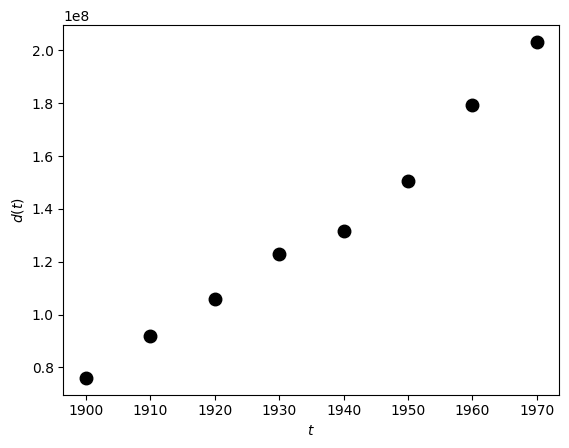

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
fig1 = plt.figure()
plt.plot(tp, dp, 'ko',  markersize=9);
plt.xlabel(r'$t$')
plt.ylabel(r'$d(t)$')

#plt.axis([0, 11, 0, 7])
plt.show()

## Exercício 2: dados de uma série temporal

Considere a tabela abaixo, elaborada a partir de um experimento com
amostragem em intervalos de 1.0 s, e proceda da forma descrita a seguir.
1. Faça um ajuste dos dados pelo métodos de mínimos quadrados, utilizando o modelo linear $d_{i}=a_{0}+a_{1}t_{i}$.
2. Elabore um gráfico do vetor de resíduos para indentificar a presença de um ponto espúrio. Elimine o ponto espúrio e repita o ajuste para comparar as novas estimativas dos parâmetos com as anteriores.
3. Exagere o desvio do ponto expúrio para verificar a sua influência no valor das estimativas dos parâmetros.
4. Troque o método de mínimos quadrados pelo de mínimos absolutos. Usando todos os 25 pontos, faça um novo ajuste e compare os resultados.
5. Examine os gráficos dos resíduos e verifique a existência de alguma estrutura que possa sugerir a necessidade de um modelo mais complexo.
6. Agora, substitua o modelo linear por $d_{i}=a_{0}+a_{1}t_{i}+a_{2}\,\mathrm{sen\,}t_{i}$. Faça um novo ajuste e comente sobre os resultados, comparando a norma do vetor de resíduos com as obtidas anteriormente.

In [ ]:
# dados
dc =np.array([ 5.0291,  6.5099,  5.3666,  4.1272,  4.2948,  6.1261, 12.5140,  10.0502,  9.1614, 7.5677,
             7.292,  10.0357, 11.0708, 13.4045, 12.8415, 11.9666, 11.0765, 11.7774,
             14.5701, 17.044,  17.1398, 15.9069, 15.485,  15.5112, 17.6572])
tc = range(1,26,1)

In [ ]:
# Função que implementa os mínimos quadrados absolutos para resolver o problema do ponto espúrio.
def lsqL1(A,b):
    teste = 0
    eps = 10e-7
    R =  np.diag(np.ones(np.size(b)))
    while teste < 10:
        AtR = A.T@R
        AtRA = AtR@A
        AtRb = AtR@b
        x = np.linalg.inv(AtRA)@AtRb
        res = b-A@x
        print("Erro: ", np.linalg.norm(res,1)/np.size(b))
        tmp_r = np.asarray(1/(abs(res) +eps))
        R = np.diag(tmp_r)
        teste = teste + 1
    return x,res

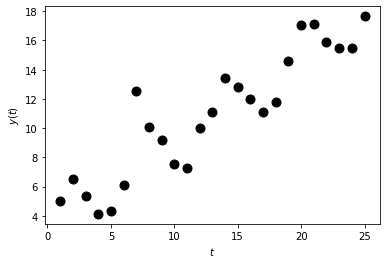

In [ ]:
plt.ion()
fig1 = plt.figure()
plt.plot(tc, dc, 'ko',  markersize=9);
plt.xlabel(r'$t$')
plt.ylabel(r'$y(t)$')

#plt.axis([0, 11, 0, 7])
plt.show()